# Notebook 05 — Phase 4 Experiments

Controlled ablation study over the two-tower model from `04_two_towers.ipynb`.

**Scope** (matches `checklist.md` Phase 4):
- **A** — feature ablations: A0 baseline, A1–A2 (user tower), A3–A4 (item tower)
- **B** — negative sampling strategy: B1 popularity-weighted, B2 hard-from-label==0

7 training runs. Seed = 42 everywhere. Sampled-eval negatives are also seeded.

**Execution order**: run A0 first → run the mining cell → run the rest of the loop (idempotent; re-runs skip completed runs).


## Setup

### Environment setup — run once, then restart

The cell below pins `torch>=2.4` (older Colab images ship 2.3.x, where `torch.amp.GradScaler` does not exist).

**After running it, do `Runtime -> Restart session` once, then re-run the whole notebook from the top.**

On a clean restart this cell will print `Requirement already satisfied` and you can keep going.

In [ ]:
!pip install -q --upgrade "torch>=2.4"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 977.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
import os
import gc
import json
import subprocess
from dataclasses import dataclass, asdict, field
from datetime import datetime

import numpy as np
import pandas as pd


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler


In [ ]:
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


In [ ]:
# Environment snapshot for reproducibility
# Writes once per notebook session to results/pip_freeze.txt
import subprocess as _sp
_pip_txt = _sp.check_output(["pip", "freeze"], stderr=_sp.DEVNULL).decode()
print(f"pip freeze: {len(_pip_txt.splitlines())} packages")


pip freeze: 741 packages


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}  |  mem: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Using device: cuda
GPU: NVIDIA A100-SXM4-80GB  |  mem: 85.1 GB


In [ ]:
DATA_DIR    = "/content/drive/My Drive/rec_system/newV2"
RESULTS_DIR = f"{DATA_DIR}/results05_final"
CKPT_DIR    = f"{DATA_DIR}/checkpoints05_final"
CONFIG_DIR  = f"{RESULTS_DIR}/configs05"
HISTORY_DIR = f"{RESULTS_DIR}/history05"
PLOTS_DIR   = f"{RESULTS_DIR}/plots05"


In [ ]:
for d in (RESULTS_DIR, CKPT_DIR, CONFIG_DIR, HISTORY_DIR, PLOTS_DIR):
    os.makedirs(d, exist_ok=True)
print("Output dirs ready:")
for d in (RESULTS_DIR, CKPT_DIR, CONFIG_DIR, HISTORY_DIR, PLOTS_DIR):
    print(f"  {d}")


Output dirs ready:
  /content/drive/My Drive/rec_system/newV2/results05_final
  /content/drive/My Drive/rec_system/newV2/checkpoints05_final
  /content/drive/My Drive/rec_system/newV2/results05_final/configs05
  /content/drive/My Drive/rec_system/newV2/results05_final/history05
  /content/drive/My Drive/rec_system/newV2/results05_final/plots05


In [ ]:
# Write pip_freeze snapshot to Drive (runs after RESULTS_DIR exists)
with open(f"{RESULTS_DIR}/pip_freeze.txt", "w") as _f:
    _f.write(_pip_txt)
print(f"Saved env snapshot: {RESULTS_DIR}/pip_freeze.txt")


Saved env snapshot: /content/drive/My Drive/rec_system/newV2/results05_final/pip_freeze.txt


In [ ]:
SEED = 42  # project-wide seed for Phase 4
print(f"Project seed: {SEED}")


Project seed: 42


## Load Data

In [ ]:
train_reviews = pd.read_parquet(f"{DATA_DIR}/train_reviews.parquet")
val_reviews   = pd.read_parquet(f"{DATA_DIR}/val_reviews.parquet")
test_reviews  = pd.read_parquet(f"{DATA_DIR}/test_reviews.parquet")
print(f"Train: {len(train_reviews):,} | Val: {len(val_reviews):,} | Test: {len(test_reviews):,}")


Train: 1,990,604 | Val: 166,488 | Test: 166,488


In [ ]:
users_df      = pd.read_parquet(f"{DATA_DIR}/users.parquet")
businesses_df = pd.read_parquet(f"{DATA_DIR}/businesses.parquet")
print(f"Users: {len(users_df):,} | Businesses: {len(businesses_df):,}")


Users: 162,366 | Businesses: 44,582


In [ ]:
user_cat_emb     = np.load(f"{DATA_DIR}/user_category_embeddings.npy")
business_cat_emb = np.load(f"{DATA_DIR}/business_category_embeddings.npy")
print(f"Qwen user emb: {user_cat_emb.shape} | business emb: {business_cat_emb.shape}")
print(f"Qwen per-dim magnitude (user/biz): {np.abs(user_cat_emb).mean():.4f} / {np.abs(business_cat_emb).mean():.4f}  <-- expect ~0.03")


Qwen user emb: (162366, 1024) | business emb: (44582, 1024)
Qwen per-dim magnitude (user/biz): 0.0211 / 0.0244  <-- expect ~0.03


In [ ]:
user_emb_index     = pd.read_parquet(f"{DATA_DIR}/user_embedding_index.parquet")
business_emb_index = pd.read_parquet(f"{DATA_DIR}/business_embedding_index.parquet")

user_to_emb_idx     = {uid: i for i, uid in enumerate(user_emb_index["user_id"])}
business_to_emb_idx = {bid: i for i, bid in enumerate(business_emb_index["business_id"])}
print(f"Built id -> emb-idx maps: {len(user_to_emb_idx):,} users, {len(business_to_emb_idx):,} businesses")


Built id -> emb-idx maps: 162,366 users, 44,582 businesses


### Sanity: label distribution + interaction counts

In [ ]:
print("Label distribution per split:")
for split_name, df in [("train", train_reviews), ("val", val_reviews), ("test", test_reviews)]:
    d = df["label"].value_counts(normalize=True).to_dict()
    n1 = (df["label"] == 1).sum()
    n0 = (df["label"] == 0).sum()
    print(f"  {split_name:5s}:  label==1 {d.get(1, 0)*100:5.1f}% ({n1:>8,})   label==0 {d.get(0, 0)*100:5.1f}% ({n0:>8,})   total {len(df):>8,}")


Label distribution per split:
  train:  label==1  70.9% (1,411,589)   label==0  29.1% ( 579,015)   total 1,990,604
  val  :  label==1  70.8% ( 117,793)   label==0  29.2% (  48,695)   total  166,488
  test :  label==1  70.1% ( 116,694)   label==0  29.9% (  49,794)   total  166,488


Interactions per user (train positives):
  min=1  p10=2  p50=4  p90=18  max=911
Interactions per item (train positives):
  min=1  p10=3  p50=13  p90=92  max=2798


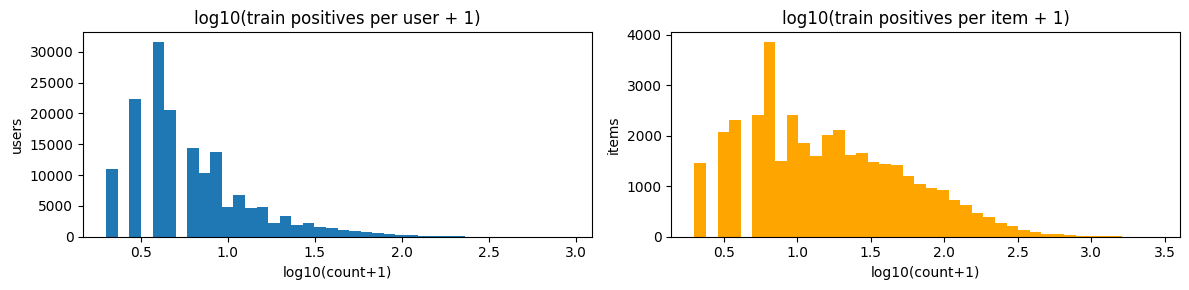

In [ ]:
u_counts = train_reviews[train_reviews["label"] == 1].groupby("user_id").size()
i_counts = train_reviews[train_reviews["label"] == 1].groupby("business_id").size()
print("Interactions per user (train positives):")
print(f"  min={u_counts.min()}  p10={u_counts.quantile(0.10):.0f}  p50={u_counts.median():.0f}  p90={u_counts.quantile(0.90):.0f}  max={u_counts.max()}")
print("Interactions per item (train positives):")
print(f"  min={i_counts.min()}  p10={i_counts.quantile(0.10):.0f}  p50={i_counts.median():.0f}  p90={i_counts.quantile(0.90):.0f}  max={i_counts.max()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(np.log10(u_counts + 1), bins=40)
axes[0].set_title("log10(train positives per user + 1)")
axes[0].set_xlabel("log10(count+1)"); axes[0].set_ylabel("users")
axes[1].hist(np.log10(i_counts + 1), bins=40, color="orange")
axes[1].set_title("log10(train positives per item + 1)")
axes[1].set_xlabel("log10(count+1)"); axes[1].set_ylabel("items")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/data_interaction_histograms.png", dpi=120, bbox_inches="tight")
plt.show()


## Feature columns

In [ ]:
USER_SCALAR_COLS_ALL = [
    "avg_stars_given",
    "review_count_log",
    "yelping_since_years",
    "is_elite",
    "avg_useful_per_review",
    "social_activity_log",
    "user_price_preference",
]
print(f"USER_SCALAR_COLS_ALL ({len(USER_SCALAR_COLS_ALL)}): {USER_SCALAR_COLS_ALL}")


USER_SCALAR_COLS_ALL (7): ['avg_stars_given', 'review_count_log', 'yelping_since_years', 'is_elite', 'avg_useful_per_review', 'social_activity_log', 'user_price_preference']


In [ ]:
BUSINESS_SCALAR_COLS_ALL = [
    "avg_stars", "review_count_log", "price_range",
    "noise_level", "alcohol", "outdoor_seating", "takes_reservations",
    "restaurants_take_out", "restaurants_delivery",
    "good_for_kids", "good_for_groups", "attire",
    "ambience_romantic", "ambience_intimate", "ambience_classy",
    "ambience_hipster", "ambience_divey", "ambience_touristy",
    "ambience_trendy", "ambience_upscale", "ambience_casual",
    "good_for_meal_breakfast", "good_for_meal_brunch", "good_for_meal_lunch",
    "good_for_meal_dinner", "good_for_meal_latenight", "good_for_meal_dessert",
]
print(f"BUSINESS_SCALAR_COLS_ALL ({len(BUSINESS_SCALAR_COLS_ALL)}):")
for c in BUSINESS_SCALAR_COLS_ALL:
    print(f"  {c}")


BUSINESS_SCALAR_COLS_ALL (27):
  avg_stars
  review_count_log
  price_range
  noise_level
  alcohol
  outdoor_seating
  takes_reservations
  restaurants_take_out
  restaurants_delivery
  good_for_kids
  good_for_groups
  attire
  ambience_romantic
  ambience_intimate
  ambience_classy
  ambience_hipster
  ambience_divey
  ambience_touristy
  ambience_trendy
  ambience_upscale
  ambience_casual
  good_for_meal_breakfast
  good_for_meal_brunch
  good_for_meal_lunch
  good_for_meal_dinner
  good_for_meal_latenight
  good_for_meal_dessert


In [ ]:
# A-family subsets (match checklist phrasings)
USER_ENGAGEMENT_COLS = [
    "review_count_log", "yelping_since_years", "is_elite",
    "avg_useful_per_review", "social_activity_log",
]
USER_MINIMAL_COLS       = ["review_count_log", "avg_stars_given"]
BUSINESS_RATING_COLS    = ["avg_stars", "review_count_log", "price_range"]
BUSINESS_ATTRIBUTE_COLS = [c for c in BUSINESS_SCALAR_COLS_ALL if c not in BUSINESS_RATING_COLS]
print(f"User subsets   : engagement={len(USER_ENGAGEMENT_COLS)}, minimal={len(USER_MINIMAL_COLS)}")
print(f"  USER_ENGAGEMENT_COLS = {USER_ENGAGEMENT_COLS}")
print(f"  USER_MINIMAL_COLS    = {USER_MINIMAL_COLS}")
print(f"Item subsets   : ratings={len(BUSINESS_RATING_COLS)}, attrs={len(BUSINESS_ATTRIBUTE_COLS)}")
print(f"  BUSINESS_RATING_COLS    = {BUSINESS_RATING_COLS}")


User subsets   : engagement=5, minimal=2
  USER_ENGAGEMENT_COLS = ['review_count_log', 'yelping_since_years', 'is_elite', 'avg_useful_per_review', 'social_activity_log']
  USER_MINIMAL_COLS    = ['review_count_log', 'avg_stars_given']
Item subsets   : ratings=3, attrs=24
  BUSINESS_RATING_COLS    = ['avg_stars', 'review_count_log', 'price_range']


## Preprocessing

In [ ]:
# NA imputation (medians) on the superset
na_before = businesses_df[BUSINESS_SCALAR_COLS_ALL].isnull().sum().sum()
for col in BUSINESS_SCALAR_COLS_ALL:
    if businesses_df[col].isnull().any():
        businesses_df[col] = businesses_df[col].fillna(businesses_df[col].median())
na_after = businesses_df[BUSINESS_SCALAR_COLS_ALL].isnull().sum().sum()
print(f"NA imputation: {na_before:,} -> {na_after:,}")


NA imputation: 489,383 -> 0


In [ ]:
from sklearn.preprocessing import StandardScaler

train_users_set      = set(train_reviews["user_id"].unique())
train_businesses_set = set(train_reviews["business_id"].unique())

user_scaler = StandardScaler().fit(
    users_df[users_df["user_id"].isin(train_users_set)][USER_SCALAR_COLS_ALL]
)
business_scaler = StandardScaler().fit(
    businesses_df[businesses_df["business_id"].isin(train_businesses_set)][BUSINESS_SCALAR_COLS_ALL]
)
print(f"Fit StandardScalers on {len(train_users_set):,} train users / {len(train_businesses_set):,} train businesses")


Fit StandardScalers on 166,488 train users / 39,111 train businesses


In [ ]:
users_df[USER_SCALAR_COLS_ALL]          = user_scaler.transform(users_df[USER_SCALAR_COLS_ALL])
businesses_df[BUSINESS_SCALAR_COLS_ALL] = business_scaler.transform(businesses_df[BUSINESS_SCALAR_COLS_ALL])
print(f"User scalars after scaling:    mean={users_df[USER_SCALAR_COLS_ALL].mean().mean():+.4f}  std={users_df[USER_SCALAR_COLS_ALL].std().mean():.4f}")
print(f"Biz scalars after scaling:     mean={businesses_df[BUSINESS_SCALAR_COLS_ALL].mean().mean():+.4f}  std={businesses_df[BUSINESS_SCALAR_COLS_ALL].std().mean():.4f}")


User scalars after scaling:    mean=+0.0000  std=1.0000
Biz scalars after scaling:     mean=-0.0194  std=0.9700


In [ ]:
# L2-normalize Qwen (raw per-dim ~0.03 vs std-1 scalars otherwise dominate)
u_pre = np.abs(user_cat_emb).mean()
b_pre = np.abs(business_cat_emb).mean()
user_cat_emb     = (user_cat_emb     / (np.linalg.norm(user_cat_emb,     axis=1, keepdims=True) + 1e-8)).astype(np.float32)
business_cat_emb = (business_cat_emb / (np.linalg.norm(business_cat_emb, axis=1, keepdims=True) + 1e-8)).astype(np.float32)
print(f"Qwen user per-dim |x|:  {u_pre:.4f} -> {np.abs(user_cat_emb).mean():.4f}     (L2-norm -> ||x||=1)")
print(f"Qwen biz  per-dim |x|:  {b_pre:.4f} -> {np.abs(business_cat_emb).mean():.4f}")


Qwen user per-dim |x|:  0.0211 -> 0.0244     (L2-norm -> ||x||=1)
Qwen biz  per-dim |x|:  0.0244 -> 0.0244


## Aligned feature matrices

Precompute once: scalar matrices and Qwen matrices aligned to user_id / business_id. Per-config feature builds just slice columns.

In [ ]:
user_ids_ordered   = users_df["user_id"].tolist()
user_id_to_idx     = {uid: i for i, uid in enumerate(user_ids_ordered)}
users_scalars_full = users_df[USER_SCALAR_COLS_ALL].values.astype(np.float32)
user_qwen_aligned  = np.stack(
    [user_cat_emb[user_to_emb_idx[uid]] for uid in user_ids_ordered]
).astype(np.float32)
print(f"user_scalars_full={users_scalars_full.shape}  user_qwen_aligned={user_qwen_aligned.shape}")


user_scalars_full=(162366, 7)  user_qwen_aligned=(162366, 1024)


In [ ]:
business_ids_ordered    = businesses_df["business_id"].tolist()
business_id_to_idx      = {bid: i for i, bid in enumerate(business_ids_ordered)}
businesses_scalars_full = businesses_df[BUSINESS_SCALAR_COLS_ALL].values.astype(np.float32)
business_qwen_aligned   = np.stack(
    [business_cat_emb[business_to_emb_idx[bid]] for bid in business_ids_ordered]
).astype(np.float32)
print(f"biz_scalars_full={businesses_scalars_full.shape}  biz_qwen_aligned={business_qwen_aligned.shape}")


biz_scalars_full=(44582, 27)  biz_qwen_aligned=(44582, 1024)


In [ ]:
def build_feature_matrices(user_cols, biz_cols, use_user_qwen, use_biz_qwen):
    """Return (user_feats, item_feats) aligned to user_id_to_idx / business_id_to_idx."""
    u_idx = [USER_SCALAR_COLS_ALL.index(c) for c in user_cols]
    b_idx = [BUSINESS_SCALAR_COLS_ALL.index(c) for c in biz_cols]
    u_scalars = users_scalars_full[:, u_idx] if u_idx else np.empty((users_scalars_full.shape[0], 0), np.float32)
    b_scalars = businesses_scalars_full[:, b_idx] if b_idx else np.empty((businesses_scalars_full.shape[0], 0), np.float32)
    u_parts = [u_scalars] + ([user_qwen_aligned]     if use_user_qwen else [])
    b_parts = [b_scalars] + ([business_qwen_aligned] if use_biz_qwen  else [])
    return (np.concatenate(u_parts, axis=1).astype(np.float32),
            np.concatenate(b_parts, axis=1).astype(np.float32))


In [ ]:
# Sanity: what dims do each config produce?
_sanity_configs = [
    ("A0 (baseline)",        USER_SCALAR_COLS_ALL,     BUSINESS_SCALAR_COLS_ALL, True, True),
    ("A1 (user engage)",     USER_ENGAGEMENT_COLS,     BUSINESS_SCALAR_COLS_ALL, True, True),
    ("A2 (user minimal)",    USER_MINIMAL_COLS,        BUSINESS_SCALAR_COLS_ALL, True, True),
    ("A3 (item ratings)",    USER_SCALAR_COLS_ALL,     BUSINESS_RATING_COLS,     True, True),
    ("A4 (item general)",    USER_SCALAR_COLS_ALL,     BUSINESS_ATTRIBUTE_COLS,  True, True),
]
print(f"{'config':<24s} {'user_dim':>10s} {'item_dim':>10s}")
for name, u, b, uq, bq in _sanity_configs:
    uf, bf = build_feature_matrices(u, b, uq, bq)
    print(f"{name:<24s} {uf.shape[1]:>10d} {bf.shape[1]:>10d}")
del _sanity_configs


config                     user_dim   item_dim
A0 (baseline)                  1031       1051
A1 (user engage)               1029       1051
A2 (user minimal)              1026       1051
A3 (item ratings)              1031       1027
A4 (item general)              1031       1048


## Library — Model

In [ ]:
class Tower(nn.Module):
    def __init__(self, input_dim, embedding_dim=128, hidden_dims=(512, 256), dropout=0.2):
        super().__init__()
        self.input_norm = nn.LayerNorm(input_dim)
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.LayerNorm(h), nn.GELU(), nn.Dropout(dropout)]
            prev = h
        self.hidden = nn.Sequential(*layers)
        self.output = nn.Linear(prev, embedding_dim)

    def forward(self, x):
        return self.output(self.hidden(self.input_norm(x)))


In [ ]:
class TwoTowerModel(nn.Module):
    def __init__(self, user_input_dim, item_input_dim, embedding_dim=128,
                 hidden_dims=(512, 256), dropout=0.2):
        super().__init__()
        self.user_tower = Tower(user_input_dim, embedding_dim, hidden_dims, dropout)
        self.item_tower = Tower(item_input_dim, embedding_dim, hidden_dims, dropout)
        self.embedding_dim = embedding_dim

    def forward(self, user_feats, item_feats):
        return (F.normalize(self.user_tower(user_feats), dim=1),
                F.normalize(self.item_tower(item_feats), dim=1))

    def encode_user(self, x): return F.normalize(self.user_tower(x), dim=1)
    def encode_item(self, x): return F.normalize(self.item_tower(x), dim=1)


## Library — Datasets

In [ ]:
class PairDataset(Dataset):
    """For InfoNCE. Yields (user_idx, item_idx) for label==1 rows only."""
    def __init__(self, reviews_df, user_id_to_idx, business_id_to_idx):
        df = reviews_df[reviews_df["label"] == 1]
        df = df[df["user_id"].isin(user_id_to_idx) & df["business_id"].isin(business_id_to_idx)]
        self.user_idx = torch.tensor([user_id_to_idx[u] for u in df["user_id"]], dtype=torch.long)
        self.item_idx = torch.tensor([business_id_to_idx[b] for b in df["business_id"]], dtype=torch.long)

    def __len__(self): return len(self.user_idx)
    def __getitem__(self, i): return self.user_idx[i], self.item_idx[i]


## Library — Losses

In [ ]:
class InfoNCELoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, user_emb, item_emb, extra_neg_emb=None):
        """extra_neg_emb: optional (B, K, D) per-anchor extras appended to the denominator."""
        B = user_emb.size(0)
        scores = (user_emb @ item_emb.T) / self.temperature                  # (B, B)
        if extra_neg_emb is not None:
            extra = torch.einsum("bd,bkd->bk", user_emb, extra_neg_emb) / self.temperature  # (B, K)
            scores = torch.cat([scores, extra], dim=1)                       # (B, B+K)
        targets = torch.arange(B, device=user_emb.device)
        return F.cross_entropy(scores, targets)


## Library — Samplers + Collates

In [ ]:
def compute_item_popularity_weights(train_df, business_id_to_idx, power=0.75):
    """Item freq^power from train positives, aligned to business_id_to_idx order."""
    counts = train_df[train_df["label"] == 1].groupby("business_id").size()
    w = np.zeros(len(business_id_to_idx), dtype=np.float32)
    for bid, cnt in counts.items():
        if bid in business_id_to_idx:
            w[business_id_to_idx[bid]] = cnt
    w = w ** power
    s = w.sum()
    return w / s if s > 0 else w


In [ ]:
def make_augmented_collate(extra_by_uidx, k, seed):
    """Collate that also yields (extras: LongTensor(B, k)) per row. Used for B2."""
    rng = np.random.default_rng(seed)
    n_biz = len(business_id_to_idx)
    def collate(batch):
        u = torch.stack([b[0] for b in batch])
        i = torch.stack([b[1] for b in batch])
        extras = np.empty((len(batch), k), dtype=np.int64)
        for row, uidx in enumerate(u.tolist()):
            pool = extra_by_uidx.get(uidx)
            if pool:
                extras[row] = rng.choice(pool, size=k, replace=(len(pool) < k))
            else:
                extras[row] = rng.integers(0, n_biz, size=k)
        return u, i, torch.tensor(extras, dtype=torch.long)
    return collate


## Library — Training

In [ ]:
def train_epoch(model, loader, optimizer, loss_fn, scaler, mode,
                user_feats, item_feats, device):
    model.train()
    total, n = 0.0, 0
    pbar = tqdm(loader, desc="train", leave=False)
    for batch in pbar:
        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            if mode == "infonce":
                u_idx, i_idx = batch[0].to(device), batch[1].to(device)
                ue, ie = model(user_feats[u_idx], item_feats[i_idx])
                loss = loss_fn(ue, ie)
            elif mode == "infonce_neg":
                u_idx, i_idx, n_idx = batch[0].to(device), batch[1].to(device), batch[2].to(device)
                ue, ie = model(user_feats[u_idx], item_feats[i_idx])
                flat_neg = model.encode_item(item_feats[n_idx.reshape(-1)])
                extra_emb = flat_neg.view(n_idx.shape[0], n_idx.shape[1], -1)
                loss = loss_fn(ue, ie, extra_emb)
            else:
                raise ValueError(f"unknown training mode: {mode!r}")
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total += loss.item()
        n += 1
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
    return total / max(n, 1)


In [ ]:
def validate(model, loader, loss_fn, mode, user_feats, item_feats, device):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in tqdm(loader, desc="val", leave=False):
            with torch.amp.autocast("cuda"):
                if mode == "infonce":
                    u_idx, i_idx = batch[0].to(device), batch[1].to(device)
                    ue, ie = model(user_feats[u_idx], item_feats[i_idx])
                    loss = loss_fn(ue, ie)
                elif mode == "infonce_neg":
                    u_idx, i_idx, n_idx = batch[0].to(device), batch[1].to(device), batch[2].to(device)
                    ue, ie = model(user_feats[u_idx], item_feats[i_idx])
                    flat_neg = model.encode_item(item_feats[n_idx.reshape(-1)])
                    extra_emb = flat_neg.view(n_idx.shape[0], n_idx.shape[1], -1)
                    loss = loss_fn(ue, ie, extra_emb)
                else:
                    raise ValueError(f"unknown training mode: {mode!r}")
            total += loss.item()
            n += 1
    return total / max(n, 1)


## Library — Evaluation

In [ ]:
def evaluate_sampled(model, eval_df, train_df, user_feats, item_feats, device,
                     n_negatives=99, ks=(5, 10, 20), seed=42):
    """1 pos + 99 seeded random negs, train-seen excluded. Returns metric dict."""
    rng = np.random.default_rng(seed)
    all_bids = np.array(list(business_id_to_idx.keys()))
    user_seen = train_df[train_df["label"] == 1].groupby("user_id")["business_id"].apply(set).to_dict()
    pos = eval_df[(eval_df["label"] == 1)
                  & eval_df["user_id"].isin(user_id_to_idx)
                  & eval_df["business_id"].isin(business_id_to_idx)]
    ranks = []
    model.eval()
    with torch.no_grad():
        for uid, pos_bid in tqdm(zip(pos["user_id"].values, pos["business_id"].values),
                                 total=len(pos), desc="sampled eval", leave=False):
            seen = user_seen.get(uid, set())
            pool = rng.choice(all_bids, n_negatives * 3, replace=False)
            negs = [b for b in pool if b not in seen and b != pos_bid][:n_negatives]
            if len(negs) < n_negatives:
                continue
            cand = torch.tensor(
                [business_id_to_idx[pos_bid]] + [business_id_to_idx[b] for b in negs],
                dtype=torch.long, device=device,
            )
            u = torch.tensor([user_id_to_idx[uid]], dtype=torch.long, device=device)
            ue = model.encode_user(user_feats[u])
            ie = model.encode_item(item_feats[cand])
            scores = (ue @ ie.T).squeeze(0).cpu().numpy()
            ranks.append(int((scores > scores[0]).sum()) + 1)
    ranks = np.array(ranks)
    out = {}
    for k in ks:
        hits = (ranks <= k).astype(float)
        out[f"sampled_ndcg_{k}"]      = float(np.where(ranks <= k, 1.0 / np.log2(ranks + 1), 0.0).mean())
        out[f"sampled_recall_{k}"]    = float(hits.mean())
        out[f"sampled_precision_{k}"] = float((hits / k).mean())
        out[f"sampled_hit_{k}"]       = float(hits.mean())
    out["sampled_mrr"] = float((1.0 / ranks).mean())
    return out


In [ ]:
def evaluate_ranking(model, eval_df, train_df, user_feats, item_feats, device, ks=(5, 10, 20)):
    """Full-catalogue (1 pos vs all ~44k items), train-seen masked out."""
    model.eval()
    n_biz = len(business_id_to_idx)
    with torch.no_grad():
        idx = torch.arange(n_biz, device=device)
        item_embs = []
        for i in range(0, n_biz, 2048):
            item_embs.append(model.encode_item(item_feats[idx[i:i+2048]]).cpu())
        item_embs = torch.cat(item_embs, dim=0)

    seen_by_uidx = {}
    for uid, group in train_df[train_df["label"] == 1].groupby("user_id"):
        if uid not in user_id_to_idx:
            continue
        seen_by_uidx[user_id_to_idx[uid]] = [
            business_id_to_idx[b] for b in group["business_id"] if b in business_id_to_idx
        ]

    pos = eval_df[(eval_df["label"] == 1)
                  & eval_df["user_id"].isin(user_id_to_idx)
                  & eval_df["business_id"].isin(business_id_to_idx)].reset_index(drop=True)
    ranks = []
    with torch.no_grad():
        bsz = 512
        for start in tqdm(range(0, len(pos), bsz), desc="full-cat eval", leave=False):
            end = min(start + bsz, len(pos))
            rows = pos.iloc[start:end]
            u_idx = torch.tensor([user_id_to_idx[u] for u in rows["user_id"]], dtype=torch.long, device=device)
            ue = model.encode_user(user_feats[u_idx]).cpu()
            scores = (ue @ item_embs.T).numpy()
            for i, (_, row) in enumerate(rows.iterrows()):
                target = business_id_to_idx[row["business_id"]]
                uidx = user_id_to_idx[row["user_id"]]
                seen = [s for s in seen_by_uidx.get(uidx, []) if s != target]
                if seen:
                    scores[i, seen] = -np.inf
                ranks.append(int((scores[i] > scores[i, target]).sum()) + 1)
    ranks = np.array(ranks)
    out = {}
    for k in ks:
        hits = (ranks <= k).astype(float)
        out[f"full_ndcg_{k}"]      = float(np.where(ranks <= k, 1.0 / np.log2(ranks + 1), 0.0).mean())
        out[f"full_recall_{k}"]    = float(hits.mean())
        out[f"full_precision_{k}"] = float((hits / k).mean())
        out[f"full_hit_{k}"]       = float(hits.mean())
    out["full_mrr"] = float((1.0 / ranks).mean())
    return out


## Library — Hard-neg mining

For B2. Score each user's label==0 items under A0; return top-k per user.

In [ ]:
def mine_hard_from_label0(model, user_feats, item_feats, train_df, device, k=16):
    """For B2. Score each user's label==0 items under the model; return top-k per user.

    Returns {user_idx: [business_idx, ...]} where all business_idx are drawn from that
    user's own label==0 interactions. Users with zero label==0 rows are omitted.
    """
    model.eval()
    negs_by_uid = train_df[train_df["label"] == 0].groupby("user_id")["business_id"].apply(list).to_dict()
    hard = {}
    with torch.no_grad():
        for uid, bids in tqdm(negs_by_uid.items(), desc="mining hard negs (label==0)", leave=False):
            if uid not in user_id_to_idx:
                continue
            cand = [business_id_to_idx[b] for b in bids if b in business_id_to_idx]
            if not cand:
                continue
            u = torch.tensor([user_id_to_idx[uid]], dtype=torch.long, device=device)
            ue = model.encode_user(user_feats[u])
            ci = torch.tensor(cand, dtype=torch.long, device=device)
            ie = model.encode_item(item_feats[ci])
            scores = (ue @ ie.T).squeeze(0)
            top_local = torch.topk(scores, min(k, len(cand))).indices.cpu().tolist()
            hard[user_id_to_idx[uid]] = [cand[i] for i in top_local]
    return hard


## Library — Orchestrator

In [ ]:
@dataclass
class ExperimentConfig:
    run_id: str
    family: str
    user_scalar_cols: tuple = field(default_factory=lambda: tuple(USER_SCALAR_COLS_ALL))
    business_scalar_cols: tuple = field(default_factory=lambda: tuple(BUSINESS_SCALAR_COLS_ALL))
    use_user_qwen: bool = True
    use_business_qwen: bool = True
    embedding_dim: int = 128
    hidden_dims: tuple = (512, 256)
    dropout: float = 0.2
    loss: str = "infonce"
    nss: str = "in_batch_random"    # "in_batch_random" | "in_batch_popularity" | "hard_label0"
    temperature: float = 0.07
    batch_size: int = 4096
    lr: float = 1e-3
    weight_decay: float = 1e-5
    num_epochs: int = 75
    patience: int = 5
    hard_negs_per_anchor: int = 16
    seed: int = 42
    notes: str = ""

    def to_dict(self):
        d = asdict(self)
        d["user_scalar_cols"]     = list(d["user_scalar_cols"])
        d["business_scalar_cols"] = list(d["business_scalar_cols"])
        d["hidden_dims"]          = list(d["hidden_dims"])
        return d


In [ ]:
def set_all_seeds(seed):
    """Called at the top of every run_experiment so sequential runs don't pollute RNG."""
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [ ]:
def _git_sha():
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"], stderr=subprocess.DEVNULL
        ).strip().decode()
    except Exception:
        return "unknown"


In [ ]:
def append_results_row(row):
    path = f"{RESULTS_DIR}/experiments.parquet"
    df = pd.DataFrame([row])
    if os.path.exists(path):
        df = pd.concat([pd.read_parquet(path), df], ignore_index=True)
    df.to_parquet(path, index=False)


In [ ]:
def load_hard_negs():
    path = f"{DATA_DIR}/hard_negs_a0.parquet"
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{path} missing — run the hard-neg mining cell after A0 completes."
        )
    df = pd.read_parquet(path)
    return {int(u): list(ns) for u, ns in zip(df["user_idx"], df["hard_negs"])}


In [ ]:
def print_metrics_summary(run_id, sampled, full):
    """Pretty-print NDCG / Recall / Precision / Hit at K ∈ {5, 10, 20}."""
    print(f"\n[{run_id}] eval metrics @ K ∈ {{5, 10, 20}}")
    print("  Sampled (1 pos + 99 negs):")
    print(f"    {'K':>3}   {'NDCG':>7}   {'Recall':>7}   {'Precision':>10}   {'Hit':>6}")
    for k in (5, 10, 20):
        print(f"    {k:>3}   "
              f"{sampled[f'sampled_ndcg_{k}']:>7.4f}   "
              f"{sampled[f'sampled_recall_{k}']:>7.4f}   "
              f"{sampled[f'sampled_precision_{k}']:>10.4f}   "
              f"{sampled[f'sampled_hit_{k}']:>6.4f}")
    print("  Full catalogue (1 pos vs all items):")
    print(f"    {'K':>3}   {'NDCG':>7}   {'Recall':>7}   {'Precision':>10}   {'Hit':>6}")
    for k in (5, 10, 20):
        print(f"    {k:>3}   "
              f"{full[f'full_ndcg_{k}']:>7.4f}   "
              f"{full[f'full_recall_{k}']:>7.4f}   "
              f"{full[f'full_precision_{k}']:>10.4f}   "
              f"{full[f'full_hit_{k}']:>6.4f}")
    print(f"  MRR (full): {full['full_mrr']:.4f}")


In [ ]:
def plot_training_curve(run_id, train_losses, val_losses, best_epoch):
    fig, ax = plt.subplots(figsize=(8, 3))
    epochs = range(1, len(train_losses) + 1)
    ax.plot(epochs, train_losses, label="train", marker="o", markersize=3)
    ax.plot(epochs, val_losses,   label="val",   marker="s", markersize=3)
    ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.4, label=f"best val @ epoch {best_epoch}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title(f"[{run_id}] training curve")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PLOTS_DIR}/{run_id}_training_curve.png", dpi=120, bbox_inches="tight")
    plt.show()


In [ ]:
def run_experiment(cfg):
    """Full training + eval + artifact writing for one config. Returns metrics row dict."""
    set_all_seeds(cfg.seed)
    run_start = datetime.utcnow().isoformat()
    print(f"\n{'=' * 70}\n[{cfg.run_id}] {cfg.family} — {cfg.notes}\n{'=' * 70}")
    print(f"hparams: nss={cfg.nss} temp={cfg.temperature} batch={cfg.batch_size} "
          f"lr={cfg.lr} dropout={cfg.dropout} emb_dim={cfg.embedding_dim} seed={cfg.seed}")

    user_feats_np, item_feats_np = build_feature_matrices(
        list(cfg.user_scalar_cols), list(cfg.business_scalar_cols),
        cfg.use_user_qwen, cfg.use_business_qwen,
    )
    user_feats = torch.tensor(user_feats_np, dtype=torch.float32, device=device)
    item_feats = torch.tensor(item_feats_np, dtype=torch.float32, device=device)
    u_dim, i_dim = user_feats.shape[1], item_feats.shape[1]
    print(f"feat dims: user={u_dim} item={i_dim}")

    model = TwoTowerModel(u_dim, i_dim, cfg.embedding_dim, cfg.hidden_dims, cfg.dropout).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"model params: {n_params:,}")

    # Loaders + loss + mode dispatch
    if cfg.nss == "hard_label0":
        extra = load_hard_negs()
        print(f"loaded hard negs for {len(extra):,} users (k={cfg.hard_negs_per_anchor} per anchor)")
        train_ds = PairDataset(train_reviews, user_id_to_idx, business_id_to_idx)
        val_ds   = PairDataset(val_reviews,   user_id_to_idx, business_id_to_idx)
        coll = make_augmented_collate(extra, cfg.hard_negs_per_anchor, cfg.seed)
        train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                                  drop_last=True, collate_fn=coll)
        val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False,
                                  drop_last=True, collate_fn=coll)
        loss_fn, mode = InfoNCELoss(cfg.temperature), "infonce_neg"
    elif cfg.nss == "in_batch_popularity":
        train_ds = PairDataset(train_reviews, user_id_to_idx, business_id_to_idx)
        val_ds   = PairDataset(val_reviews,   user_id_to_idx, business_id_to_idx)
        w = compute_item_popularity_weights(train_reviews, business_id_to_idx)
        row_w = w[train_ds.item_idx.numpy()]
        sampler = WeightedRandomSampler(weights=row_w.tolist(),
                                        num_samples=len(train_ds), replacement=True)
        train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, sampler=sampler, drop_last=True)
        val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False, drop_last=True)
        loss_fn, mode = InfoNCELoss(cfg.temperature), "infonce"
    else:  # in_batch_random
        train_ds = PairDataset(train_reviews, user_id_to_idx, business_id_to_idx)
        val_ds   = PairDataset(val_reviews,   user_id_to_idx, business_id_to_idx)
        train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, drop_last=True)
        val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False, drop_last=True)
        loss_fn, mode = InfoNCELoss(cfg.temperature), "infonce"

    print(f"train batches/epoch: {len(train_loader):,}  |  val batches/epoch: {len(val_loader):,}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
    scaler    = torch.amp.GradScaler("cuda")

    ckpt_path = f"{CKPT_DIR}/{cfg.run_id}.pt"
    train_losses, val_losses = [], []
    best_val, no_improve, epochs_run, early_stopped = float("inf"), 0, 0, False
    train_start = datetime.utcnow()
    for epoch in range(cfg.num_epochs):
        t = train_epoch(model, train_loader, optimizer, loss_fn, scaler, mode,
                        user_feats, item_feats, device)
        v = validate(  model, val_loader,   loss_fn,           mode,
                        user_feats, item_feats, device)
        train_losses.append(t); val_losses.append(v)
        scheduler.step(v)
        epochs_run = epoch + 1
        lr_now = optimizer.param_groups[0]["lr"]
        new_best = v < best_val
        marker = "  <-- new best" if new_best else ""
        print(f"[{cfg.run_id}] epoch {epochs_run:2d}/{cfg.num_epochs}  train={t:.4f}  val={v:.4f}  lr={lr_now:.2e}{marker}")
        if new_best:
            best_val, no_improve = v, 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            no_improve += 1
            if no_improve >= cfg.patience:
                early_stopped = True
                print(f"[{cfg.run_id}] early stop at epoch {epochs_run} (no improvement for {cfg.patience} epochs)")
                break
    train_minutes = (datetime.utcnow() - train_start).total_seconds() / 60.0
    best_epoch = int(np.argmin(val_losses)) + 1
    print(f"\n[{cfg.run_id}] training done in {train_minutes:.1f} min | best val {best_val:.4f} at epoch {best_epoch}/{epochs_run}")

    # Load best checkpoint and evaluate
    model.load_state_dict(torch.load(ckpt_path))
    sampled = evaluate_sampled(model, test_reviews, train_reviews, user_feats, item_feats, device, seed=cfg.seed)
    full    = evaluate_ranking( model, test_reviews, train_reviews, user_feats, item_feats, device)
    print_metrics_summary(cfg.run_id, sampled, full)

    peak_mb = torch.cuda.max_memory_allocated() / 1e6 if torch.cuda.is_available() else 0.0
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    print(f"[{cfg.run_id}] peak GPU mem: {peak_mb:.0f} MB  |  elapsed: {train_minutes:.1f} min")

    row = {
        "run_id": cfg.run_id, "family": cfg.family, "seed": cfg.seed,
        "git_sha": _git_sha(), "timestamp": run_start,
        "config_json": json.dumps(cfg.to_dict()),
        "user_feat_dim": u_dim, "item_feat_dim": i_dim, "n_params": n_params,
        "loss": cfg.loss, "nss": cfg.nss, "temperature": cfg.temperature,
        "embedding_dim": cfg.embedding_dim,
        "epochs_run": epochs_run, "best_epoch": best_epoch, "early_stopped": early_stopped,
        "train_loss_final": train_losses[-1], "val_loss_final": val_losses[-1],
        "best_val_loss": best_val, "train_minutes": train_minutes, "peak_gpu_mb": peak_mb,
        "checkpoint_path": ckpt_path,
        **sampled, **full,
    }
    with open(f"{CONFIG_DIR}/{cfg.run_id}.json", "w") as f:
        json.dump(cfg.to_dict(), f, indent=2)
    pd.DataFrame({
        "epoch": range(1, epochs_run + 1),
        "train_loss": train_losses, "val_loss": val_losses,
    }).to_csv(f"{HISTORY_DIR}/{cfg.run_id}.csv", index=False)
    append_results_row(row)

    # Plot training curve
    plot_training_curve(cfg.run_id, train_losses, val_losses, best_epoch)

    del model, optimizer, train_loader, val_loader, train_ds, val_ds, user_feats, item_feats
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return row


## Experiment configs

In [ ]:
CONFIGS = [
    # --- Family A: feature ablations ---
    ExperimentConfig(run_id="A0", family="A",
                     notes="Baseline: all features, InfoNCE, random in-batch"),
    ExperimentConfig(run_id="A1", family="A",
                     user_scalar_cols=tuple(USER_ENGAGEMENT_COLS),
                     notes="User engagement-only (drops avg_stars_given + user_price_preference)"),
    ExperimentConfig(run_id="A2", family="A",
                     user_scalar_cols=tuple(USER_MINIMAL_COLS),
                     notes="User minimal: review_count_log + avg_stars_given"),
    ExperimentConfig(run_id="A3", family="A",
                     business_scalar_cols=tuple(BUSINESS_RATING_COLS),
                     notes="Item ratings-only: avg_stars, review_count_log, price_range"),
    ExperimentConfig(run_id="A4", family="A",
                     business_scalar_cols=tuple(BUSINESS_ATTRIBUTE_COLS),
                     notes="Item general (attributes only; no rating signals)"),

    # --- Family B: negative sampling strategy ---
    ExperimentConfig(run_id="B1", family="B", nss="in_batch_popularity",
                     notes="Popularity-weighted in-batch negatives (word2vec-style)"),
    ExperimentConfig(run_id="B2", family="B", nss="hard_label0",
                     notes="Hard negatives mined from top-scoring label==0 rows under A0"),

]
print(f"{len(CONFIGS)} configs queued:")
for c in CONFIGS:
    print(f"  [{c.run_id}] {c.family} — {c.notes}")


7 configs queued:
  [A0] A — Baseline: all features, InfoNCE, random in-batch
  [A1] A — User engagement-only (drops avg_stars_given + user_price_preference)
  [A2] A — User minimal: review_count_log + avg_stars_given
  [A3] A — Item ratings-only: avg_stars, review_count_log, price_range
  [A4] A — Item general (attributes only; no rating signals)
  [B1] B — Popularity-weighted in-batch negatives (word2vec-style)
  [B2] B — Hard negatives mined from top-scoring label==0 rows under A0


## Run A0 first (baseline + dependency for B2 mining)


[A0] A — Baseline: all features, InfoNCE, random in-batch
hparams: nss=in_batch_random temp=0.07 batch=4096 lr=0.001 dropout=0.2 emb_dim=128 seed=42


/tmp/ipykernel_832/1955987940.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_start = datetime.utcnow().isoformat()


feat dims: user=1031 item=1051
model params: 1,402,692
train batches/epoch: 344  |  val batches/epoch: 28


/tmp/ipykernel_832/1955987940.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  train_start = datetime.utcnow()


train:   0%|          | 0/344 [00:00<?, ?it/s]

...

[A0] epoch 75/75  train=5.0500  val=8.0507  lr=5.00e-04  <-- new best

[A0] training done in 21.9 min | best val 8.0507 at epoch 75/75


/tmp/ipykernel_832/1955987940.py:82: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  train_minutes = (datetime.utcnow() - train_start).total_seconds() / 60.0


sampled eval:   0%|          | 0/115373 [00:00<?, ?it/s]

full-cat eval:   0%|          | 0/226 [00:00<?, ?it/s]


[A0] eval metrics @ K ∈ {5, 10, 20}
  Sampled (1 pos + 99 negs):
      K      NDCG    Recall    Precision      Hit
      5    0.3183    0.4342       0.0868   0.4342
     10    0.3573    0.5548       0.0555   0.5548
     20    0.3897    0.6829       0.0341   0.6829
  Full catalogue (1 pos vs all items):
      K      NDCG    Recall    Precision      Hit
      5    0.0172    0.0218       0.0044   0.0218
     10    0.0195    0.0290       0.0029   0.0290
     20    0.0223    0.0403       0.0020   0.0403
  MRR (full): 0.0194
[A0] peak GPU mem: 1193 MB  |  elapsed: 21.9 min


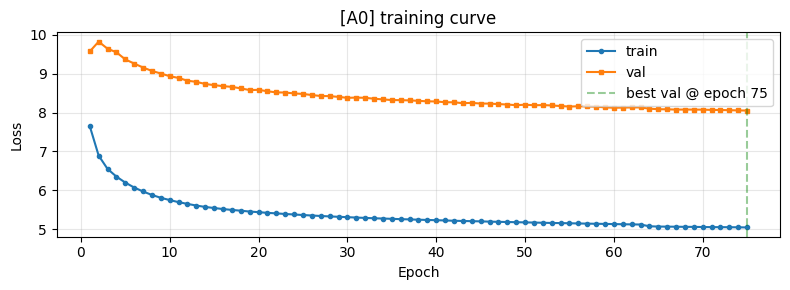

{'run_id': 'A0',
 'family': 'A',
 'seed': 42,
 'git_sha': 'unknown',
 'timestamp': '2026-04-27T22:43:09.142416',
 'config_json': '{"run_id": "A0", "family": "A", "user_scalar_cols": ["avg_stars_given", "review_count_log", "yelping_since_years", "is_elite", "avg_useful_per_review", "social_activity_log", "user_price_preference"], "business_scalar_cols": ["avg_stars", "review_count_log", "price_range", "noise_level", "alcohol", "outdoor_seating", "takes_reservations", "restaurants_take_out", "restaurants_delivery", "good_for_kids", "good_for_groups", "attire", "ambience_romantic", "ambience_intimate", "ambience_classy", "ambience_hipster", "ambience_divey", "ambience_touristy", "ambience_trendy", "ambience_upscale", "ambience_casual", "good_for_meal_breakfast", "good_for_meal_brunch", "good_for_meal_lunch", "good_for_meal_dinner", "good_for_meal_latenight", "good_for_meal_dessert"], "use_user_qwen": true, "use_business_qwen": true, "embedding_dim": 128, "hidden_dims": [512, 256], "dropou

In [ ]:
run_experiment(next(c for c in CONFIGS if c.run_id == "A0"))


## Mine hard negatives from A0 label==0 scoring

Only needed before B2. Skips if `hard_negs_a0.parquet` already exists.

In [ ]:
hn_path = f"{DATA_DIR}/hard_negs_a0.parquet"
if os.path.exists(hn_path):
    hn_df = pd.read_parquet(hn_path)
    print(f"{hn_path} exists ({len(hn_df):,} users) — skipping mining")
else:
    a0_cfg = next(c for c in CONFIGS if c.run_id == "A0")
    uf_np, bf_np = build_feature_matrices(
        list(a0_cfg.user_scalar_cols), list(a0_cfg.business_scalar_cols),
        a0_cfg.use_user_qwen, a0_cfg.use_business_qwen,
    )
    uf = torch.tensor(uf_np, dtype=torch.float32, device=device)
    bf = torch.tensor(bf_np, dtype=torch.float32, device=device)
    model_a0 = TwoTowerModel(uf.shape[1], bf.shape[1],
                             a0_cfg.embedding_dim, a0_cfg.hidden_dims, a0_cfg.dropout).to(device)
    model_a0.load_state_dict(torch.load(f"{CKPT_DIR}/A0.pt"))
    hard = mine_hard_from_label0(model_a0, uf, bf, train_reviews, device, k=16)
    hn_df = pd.DataFrame({
        "user_idx":  list(hard.keys()),
        "hard_negs": [list(v) for v in hard.values()],
    })
    hn_df.to_parquet(hn_path, index=False)
    print(f"Wrote {len(hard):,} user -> hard-neg rows to {hn_path}")
    del model_a0, uf, bf
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


mining hard negs (label==0):   0%|          | 0/127795 [00:00<?, ?it/s]

Wrote 123,673 user -> hard-neg rows to /content/drive/My Drive/rec_system/newV2/hard_negs_a0.parquet


In [ ]:
# Sanity: distribution of how many hard negs per user
pool_sizes = hn_df["hard_negs"].apply(len)
print(f"Hard-neg pool sizes per user: "
      f"min={pool_sizes.min()}  p50={pool_sizes.median():.0f}  p90={pool_sizes.quantile(0.9):.0f}  max={pool_sizes.max()}  "
      f"users={len(hn_df):,}")
print(f"Users with < 16 hard negs (collate will resample with replacement): "
      f"{(pool_sizes < 16).sum():,} / {len(pool_sizes):,}")


Hard-neg pool sizes per user: min=1  p50=2  p90=9  max=16  users=123,673
Users with < 16 hard negs (collate will resample with replacement): 117,807 / 123,673


## Run remaining experiments

Idempotent: skips any `run_id` already recorded in `experiments.parquet`. Safe to re-run after a Colab disconnect.

Already done: ['A0']
To run:       ['A1', 'A2', 'A3', 'A4', 'B1', 'B2']

[A1] A — User engagement-only (drops avg_stars_given + user_price_preference)
hparams: nss=in_batch_random temp=0.07 batch=4096 lr=0.001 dropout=0.2 emb_dim=128 seed=42


/tmp/ipykernel_832/1955987940.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_start = datetime.utcnow().isoformat()


feat dims: user=1029 item=1051
model params: 1,401,664
train batches/epoch: 344  |  val batches/epoch: 28


/tmp/ipykernel_832/1955987940.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  train_start = datetime.utcnow()


train:   0%|          | 0/344 [00:00<?, ?it/s]

...

[A1] epoch 75/75  train=5.0418  val=8.0872  lr=1.25e-04  <-- new best

[A1] training done in 21.1 min | best val 8.0872 at epoch 75/75


/tmp/ipykernel_832/1955987940.py:82: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  train_minutes = (datetime.utcnow() - train_start).total_seconds() / 60.0


sampled eval:   0%|          | 0/115373 [00:00<?, ?it/s]

full-cat eval:   0%|          | 0/226 [00:00<?, ?it/s]


[A1] eval metrics @ K ∈ {5, 10, 20}
  Sampled (1 pos + 99 negs):
      K      NDCG    Recall    Precision      Hit
      5    0.3143    0.4296       0.0859   0.4296
     10    0.3525    0.5479       0.0548   0.5479
     20    0.3850    0.6766       0.0338   0.6766
  Full catalogue (1 pos vs all items):
      K      NDCG    Recall    Precision      Hit
      5    0.0172    0.0221       0.0044   0.0221
     10    0.0195    0.0292       0.0029   0.0292
     20    0.0221    0.0395       0.0020   0.0395
  MRR (full): 0.0193
[A1] peak GPU mem: 1192 MB  |  elapsed: 21.1 min


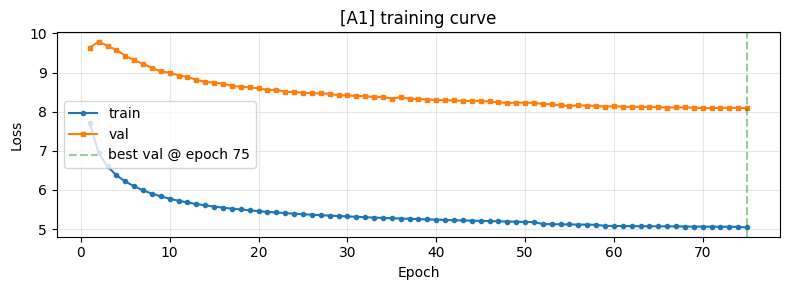

/tmp/ipykernel_832/1955987940.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_start = datetime.utcnow().isoformat()



[A2] A — User minimal: review_count_log + avg_stars_given
hparams: nss=in_batch_random temp=0.07 batch=4096 lr=0.001 dropout=0.2 emb_dim=128 seed=42
feat dims: user=1026 item=1051
model params: 1,400,122
train batches/epoch: 344  |  val batches/epoch: 28


/tmp/ipykernel_832/1955987940.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  train_start = datetime.utcnow()


train:   0%|          | 0/344 [00:00<?, ?it/s]

val:   0%|          | 0/28 [00:00<?, ?it/s]

...

[A2] epoch 75/75  train=5.0899  val=8.0996  lr=1.00e-03  <-- new best

[A2] training done in 21.2 min | best val 8.0996 at epoch 75/75


/tmp/ipykernel_832/1955987940.py:82: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  train_minutes = (datetime.utcnow() - train_start).total_seconds() / 60.0


sampled eval:   0%|          | 0/115373 [00:00<?, ?it/s]

full-cat eval:   0%|          | 0/226 [00:00<?, ?it/s]


[A2] eval metrics @ K ∈ {5, 10, 20}
  Sampled (1 pos + 99 negs):
      K      NDCG    Recall    Precision      Hit
      5    0.3169    0.4329       0.0866   0.4329
     10    0.3552    0.5514       0.0551   0.5514
     20    0.3871    0.6776       0.0339   0.6776
  Full catalogue (1 pos vs all items):
      K      NDCG    Recall    Precision      Hit
      5    0.0171    0.0219       0.0044   0.0219
     10    0.0194    0.0290       0.0029   0.0290
     20    0.0221    0.0400       0.0020   0.0400
  MRR (full): 0.0193
[A2] peak GPU mem: 1190 MB  |  elapsed: 21.2 min


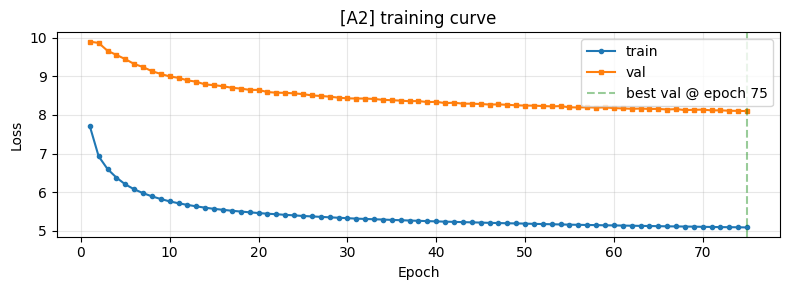

/tmp/ipykernel_832/1955987940.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_start = datetime.utcnow().isoformat()



[A3] A — Item ratings-only: avg_stars, review_count_log, price_range
hparams: nss=in_batch_random temp=0.07 batch=4096 lr=0.001 dropout=0.2 emb_dim=128 seed=42
feat dims: user=1031 item=1027
model params: 1,390,356
train batches/epoch: 344  |  val batches/epoch: 28


/tmp/ipykernel_832/1955987940.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  train_start = datetime.utcnow()


train:   0%|          | 0/344 [00:00<?, ?it/s]

val:   0%|          | 0/28 [00:00<?, ?it/s]

...

[A3] epoch 75/75  train=5.2069  val=8.3454  lr=2.50e-04  <-- new best

[A3] training done in 21.6 min | best val 8.3454 at epoch 75/75


/tmp/ipykernel_832/1955987940.py:82: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  train_minutes = (datetime.utcnow() - train_start).total_seconds() / 60.0


sampled eval:   0%|          | 0/115373 [00:00<?, ?it/s]

full-cat eval:   0%|          | 0/226 [00:00<?, ?it/s]


[A3] eval metrics @ K ∈ {5, 10, 20}
  Sampled (1 pos + 99 negs):
      K      NDCG    Recall    Precision      Hit
      5    0.2766    0.3775       0.0755   0.3775
     10    0.3134    0.4915       0.0492   0.4915
     20    0.3462    0.6214       0.0311   0.6214
  Full catalogue (1 pos vs all items):
      K      NDCG    Recall    Precision      Hit
      5    0.0165    0.0211       0.0042   0.0211
     10    0.0186    0.0274       0.0027   0.0274
     20    0.0210    0.0371       0.0019   0.0371
  MRR (full): 0.0184
[A3] peak GPU mem: 1187 MB  |  elapsed: 21.6 min


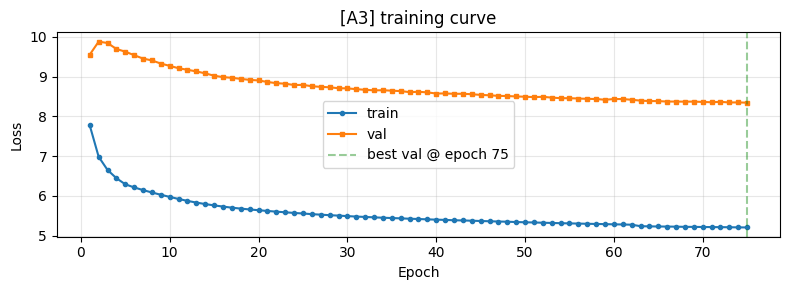

/tmp/ipykernel_832/1955987940.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_start = datetime.utcnow().isoformat()



[A4] A — Item general (attributes only; no rating signals)
hparams: nss=in_batch_random temp=0.07 batch=4096 lr=0.001 dropout=0.2 emb_dim=128 seed=42
feat dims: user=1031 item=1048
model params: 1,401,150
train batches/epoch: 344  |  val batches/epoch: 28


/tmp/ipykernel_832/1955987940.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  train_start = datetime.utcnow()


train:   0%|          | 0/344 [00:00<?, ?it/s]

val:   0%|          | 0/28 [00:00<?, ?it/s]

...

[A4] epoch  6/75  train=6.1920  val=9.4986  lr=5.00e-04
[A4] early stop at epoch 6 (no improvement for 5 epochs)

[A4] training done in 1.7 min | best val 9.4985 at epoch 1/6


/tmp/ipykernel_832/1955987940.py:82: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  train_minutes = (datetime.utcnow() - train_start).total_seconds() / 60.0


sampled eval:   0%|          | 0/115373 [00:00<?, ?it/s]

full-cat eval:   0%|          | 0/226 [00:00<?, ?it/s]


[A4] eval metrics @ K ∈ {5, 10, 20}
  Sampled (1 pos + 99 negs):
      K      NDCG    Recall    Precision      Hit
      5    0.1256    0.1842       0.0368   0.1842
     10    0.1554    0.2774       0.0277   0.2774
     20    0.1896    0.4133       0.0207   0.4133
  Full catalogue (1 pos vs all items):
      K      NDCG    Recall    Precision      Hit
      5    0.0024    0.0035       0.0007   0.0035
     10    0.0031    0.0058       0.0006   0.0058
     20    0.0040    0.0094       0.0005   0.0094
  MRR (full): 0.0034
[A4] peak GPU mem: 1192 MB  |  elapsed: 1.7 min


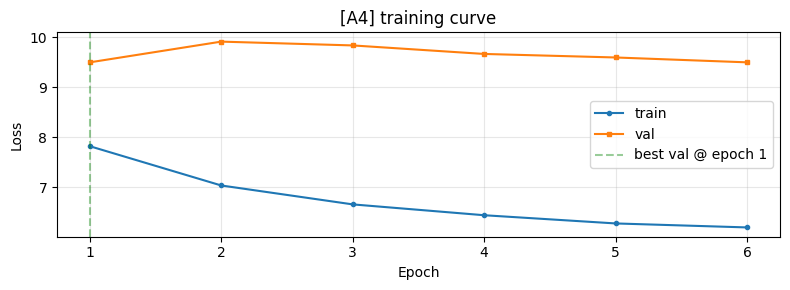

/tmp/ipykernel_832/1955987940.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_start = datetime.utcnow().isoformat()



[B1] B — Popularity-weighted in-batch negatives (word2vec-style)
hparams: nss=in_batch_popularity temp=0.07 batch=4096 lr=0.001 dropout=0.2 emb_dim=128 seed=42
feat dims: user=1031 item=1051
model params: 1,402,692
train batches/epoch: 344  |  val batches/epoch: 28


/tmp/ipykernel_832/1955987940.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  train_start = datetime.utcnow()


train:   0%|          | 0/344 [00:00<?, ?it/s]

val:   0%|          | 0/28 [00:00<?, ?it/s]

...

[B1] epoch 75/75  train=4.9253  val=8.2572  lr=6.25e-05

[B1] training done in 22.1 min | best val 8.2565 at epoch 71/75


/tmp/ipykernel_832/1955987940.py:82: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  train_minutes = (datetime.utcnow() - train_start).total_seconds() / 60.0


sampled eval:   0%|          | 0/115373 [00:00<?, ?it/s]

full-cat eval:   0%|          | 0/226 [00:00<?, ?it/s]


[B1] eval metrics @ K ∈ {5, 10, 20}
  Sampled (1 pos + 99 negs):
      K      NDCG    Recall    Precision      Hit
      5    0.2794    0.3756       0.0751   0.3756
     10    0.3125    0.4780       0.0478   0.4780
     20    0.3421    0.5954       0.0298   0.5954
  Full catalogue (1 pos vs all items):
      K      NDCG    Recall    Precision      Hit
      5    0.0177    0.0223       0.0045   0.0223
     10    0.0198    0.0291       0.0029   0.0291
     20    0.0224    0.0392       0.0020   0.0392
  MRR (full): 0.0196
[B1] peak GPU mem: 1193 MB  |  elapsed: 22.1 min


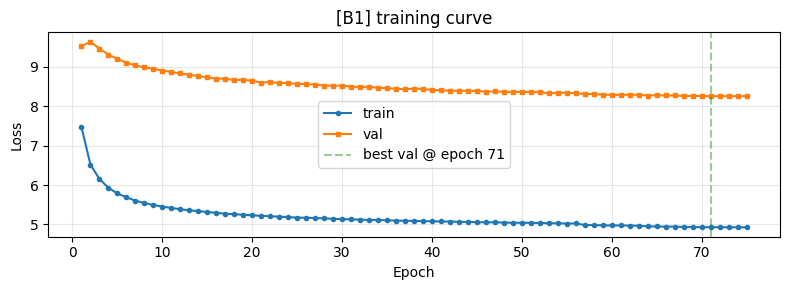

/tmp/ipykernel_832/1955987940.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  run_start = datetime.utcnow().isoformat()



[B2] B — Hard negatives mined from top-scoring label==0 rows under A0
hparams: nss=hard_label0 temp=0.07 batch=4096 lr=0.001 dropout=0.2 emb_dim=128 seed=42
feat dims: user=1031 item=1051
model params: 1,402,692
loaded hard negs for 123,673 users (k=16 per anchor)
train batches/epoch: 344  |  val batches/epoch: 28


/tmp/ipykernel_832/1955987940.py:60: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  train_start = datetime.utcnow()


train:   0%|          | 0/344 [00:00<?, ?it/s]

val:   0%|          | 0/28 [00:00<?, ?it/s]

...

[B2] epoch 75/75  train=5.0693  val=8.0988  lr=2.50e-04  <-- new best

[B2] training done in 58.8 min | best val 8.0988 at epoch 75/75


/tmp/ipykernel_832/1955987940.py:82: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  train_minutes = (datetime.utcnow() - train_start).total_seconds() / 60.0


sampled eval:   0%|          | 0/115373 [00:00<?, ?it/s]

full-cat eval:   0%|          | 0/226 [00:00<?, ?it/s]


[B2] eval metrics @ K ∈ {5, 10, 20}
  Sampled (1 pos + 99 negs):
      K      NDCG    Recall    Precision      Hit
      5    0.3150    0.4292       0.0858   0.4292
     10    0.3539    0.5496       0.0550   0.5496
     20    0.3864    0.6781       0.0339   0.6781
  Full catalogue (1 pos vs all items):
      K      NDCG    Recall    Precision      Hit
      5    0.0176    0.0225       0.0045   0.0225
     10    0.0198    0.0294       0.0029   0.0294
     20    0.0224    0.0398       0.0020   0.0398
  MRR (full): 0.0197
[B2] peak GPU mem: 2402 MB  |  elapsed: 58.8 min


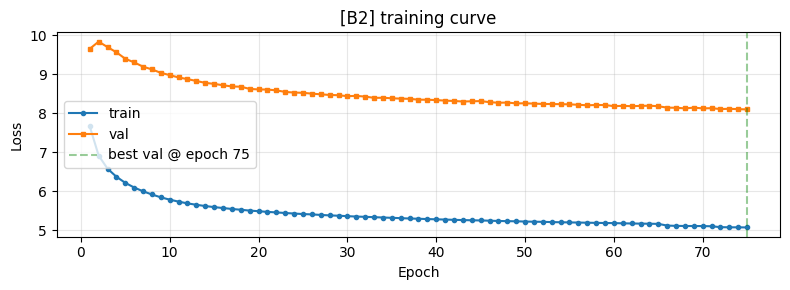

In [ ]:
res_path = f"{RESULTS_DIR}/experiments.parquet"
done = set()
if os.path.exists(res_path):
    done = set(pd.read_parquet(res_path)["run_id"].tolist())
    print(f"Already done: {sorted(done)}")
    print(f"To run:       {[c.run_id for c in CONFIGS if c.run_id not in done]}")

for cfg in CONFIGS:
    if cfg.run_id in done:
        continue
    try:
        run_experiment(cfg)
    except FileNotFoundError as e:
        print(f"[{cfg.run_id}] SKIPPED: {e}")
    except Exception as e:
        print(f"[{cfg.run_id}] FAILED: {e!r}")
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


## Results — tables

In [ ]:
res = pd.read_parquet(f"{RESULTS_DIR}/experiments.parquet").sort_values("run_id")
print(f"Loaded {len(res)} runs from experiments.parquet")
print(f"Runs: {list(res['run_id'])}")


Loaded 7 runs from experiments.parquet
Runs: ['A0', 'A1', 'A2', 'A3', 'A4', 'B1', 'B2']


In [ ]:
# Headline table: all four metric families @ K=10 (full-cat) + sampled NDCG + MRR + wall-clock
show = ["run_id", "family", "loss", "nss",
        "full_ndcg_10", "full_recall_10", "full_precision_10", "full_hit_10",
        "sampled_ndcg_10", "full_mrr",
        "epochs_run", "train_minutes"]
print(res[show].sort_values("full_ndcg_10", ascending=False).to_string(index=False, float_format=lambda x: f"{x:.4f}"))


run_id family    loss                 nss  full_ndcg_10  full_recall_10  full_precision_10  full_hit_10  sampled_ndcg_10  full_mrr  epochs_run  train_minutes
    B1      B infonce in_batch_popularity        0.0198          0.0291             0.0029       0.0291           0.3125    0.0196          75        22.1482
    B2      B infonce         hard_label0        0.0198          0.0294             0.0029       0.0294           0.3539    0.0197          75        58.7625
    A1      A infonce     in_batch_random        0.0195          0.0292             0.0029       0.0292           0.3525    0.0193          75        21.0844
    A0      A infonce     in_batch_random        0.0195          0.0290             0.0029       0.0290           0.3573    0.0194          75        21.8823
    A2      A infonce     in_batch_random        0.0194          0.0290             0.0029       0.0290           0.3552    0.0193          75        21.1595
    A3      A infonce     in_batch_random        0.0

In [ ]:
# Multi-K tables: NDCG / Recall / Precision / Hit at each K (sampled + full side by side)
for metric in ("ndcg", "recall", "precision", "hit"):
    cols = [f"{prefix}_{metric}_{k}" for k in (5, 10, 20) for prefix in ("sampled", "full")]
    print(f"\n{metric.upper()} across K (sampled | full):")
    print(res[["run_id"] + cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))



NDCG across K (sampled | full):
run_id  sampled_ndcg_5  full_ndcg_5  sampled_ndcg_10  full_ndcg_10  sampled_ndcg_20  full_ndcg_20
    A0          0.3183       0.0172           0.3573        0.0195           0.3897        0.0223
    A1          0.3143       0.0172           0.3525        0.0195           0.3850        0.0221
    A2          0.3169       0.0171           0.3552        0.0194           0.3871        0.0221
    A3          0.2766       0.0165           0.3134        0.0186           0.3462        0.0210
    A4          0.1256       0.0024           0.1554        0.0031           0.1896        0.0040
    B1          0.2794       0.0177           0.3125        0.0198           0.3421        0.0224
    B2          0.3150       0.0176           0.3539        0.0198           0.3864        0.0224

RECALL across K (sampled | full):
run_id  sampled_recall_5  full_recall_5  sampled_recall_10  full_recall_10  sampled_recall_20  full_recall_20
    A0            0.4342         0.021

In [ ]:
# Delta vs A0 (so you see the magnitude of each ablation's effect)
if "A0" in res["run_id"].values:
    a0 = res[res["run_id"] == "A0"].iloc[0]
    delta_cols = ["sampled_ndcg_10", "full_ndcg_10", "full_mrr"]
    delta = res[["run_id", "family"] + delta_cols].copy()
    for c in delta_cols:
        delta[c + "_delta_vs_A0"] = delta[c] - a0[c]
        delta[c + "_pct_vs_A0"]   = (delta[c] / a0[c] - 1) * 100
    show = ["run_id", "family"]
    for c in delta_cols:
        show += [c, c + "_delta_vs_A0", c + "_pct_vs_A0"]
    print(delta[show].to_string(index=False, float_format=lambda x: f"{x:+.4f}"))


run_id family  sampled_ndcg_10  sampled_ndcg_10_delta_vs_A0  sampled_ndcg_10_pct_vs_A0  full_ndcg_10  full_ndcg_10_delta_vs_A0  full_ndcg_10_pct_vs_A0  full_mrr  full_mrr_delta_vs_A0  full_mrr_pct_vs_A0
    A0      A          +0.3573                      +0.0000                    +0.0000       +0.0195                   +0.0000                 +0.0000   +0.0194               +0.0000             +0.0000
    A1      A          +0.3525                      -0.0048                    -1.3466       +0.0195                   +0.0000                 +0.1921   +0.0193               -0.0001             -0.6292
    A2      A          +0.3552                      -0.0021                    -0.5856       +0.0194                   -0.0001                 -0.4351   +0.0193               -0.0001             -0.6348
    A3      A          +0.3134                      -0.0439                   -12.2874       +0.0186                   -0.0009                 -4.5921   +0.0184               -0.0011      

## Results — plots

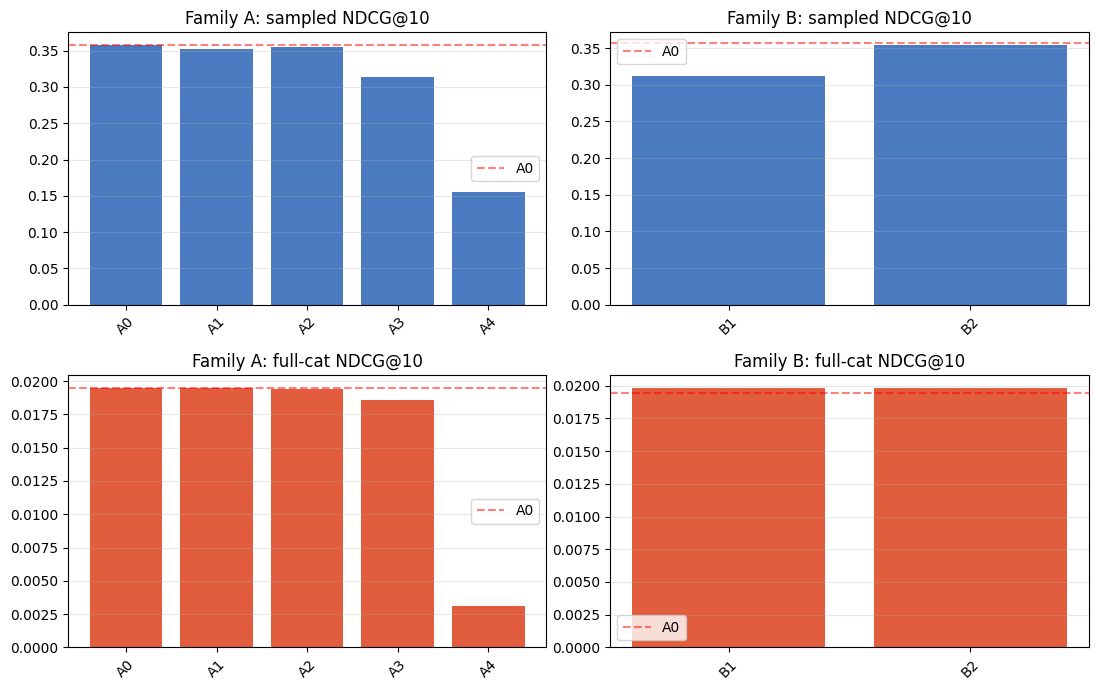

In [ ]:
# Per-family bar plot of sampled + full NDCG@10 (A0 reference shown as dashed line)
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
a0_samp = res[res["run_id"] == "A0"]["sampled_ndcg_10"].iloc[0] if "A0" in res["run_id"].values else None
a0_full = res[res["run_id"] == "A0"]["full_ndcg_10"].iloc[0]    if "A0" in res["run_id"].values else None

for col, fam in enumerate(["A", "B"]):
    sub = res[res["family"] == fam].sort_values("run_id")
    if sub.empty:
        for row in (0, 1):
            axes[row, col].set_title(f"Family {fam} (no data)")
        continue
    axes[0, col].bar(sub["run_id"], sub["sampled_ndcg_10"], color="#4a7abf")
    if a0_samp is not None:
        axes[0, col].axhline(a0_samp, color="red", linestyle="--", alpha=0.5, label="A0")
        axes[0, col].legend()
    axes[0, col].set_title(f"Family {fam}: sampled NDCG@10")
    axes[0, col].tick_params(axis="x", rotation=45)
    axes[0, col].grid(axis="y", alpha=0.3)

    axes[1, col].bar(sub["run_id"], sub["full_ndcg_10"], color="#e25c3e")
    if a0_full is not None:
        axes[1, col].axhline(a0_full, color="red", linestyle="--", alpha=0.5, label="A0")
        axes[1, col].legend()
    axes[1, col].set_title(f"Family {fam}: full-cat NDCG@10")
    axes[1, col].tick_params(axis="x", rotation=45)
    axes[1, col].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/results_ndcg_bars.png", dpi=120, bbox_inches="tight")
plt.show()


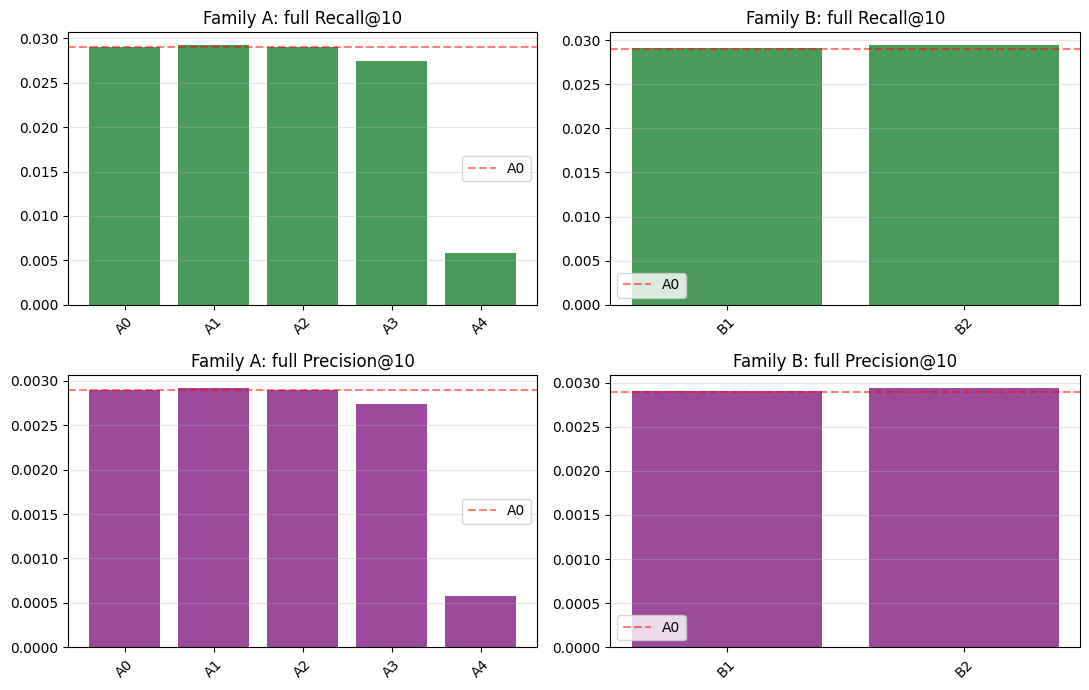

In [ ]:
# Same 2x3 grid but for full-cat Recall@10 (top row) and Precision@10 (bottom row)
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
a0_rec = res[res["run_id"] == "A0"]["full_recall_10"].iloc[0]    if "A0" in res["run_id"].values else None
a0_pre = res[res["run_id"] == "A0"]["full_precision_10"].iloc[0] if "A0" in res["run_id"].values else None

for col, fam in enumerate(["A", "B"]):
    sub = res[res["family"] == fam].sort_values("run_id")
    if sub.empty:
        for row in (0, 1):
            axes[row, col].set_title(f"Family {fam} (no data)")
        continue
    axes[0, col].bar(sub["run_id"], sub["full_recall_10"], color="#4a9b5a")
    if a0_rec is not None:
        axes[0, col].axhline(a0_rec, color="red", linestyle="--", alpha=0.5, label="A0")
        axes[0, col].legend()
    axes[0, col].set_title(f"Family {fam}: full Recall@10")
    axes[0, col].tick_params(axis="x", rotation=45)
    axes[0, col].grid(axis="y", alpha=0.3)

    axes[1, col].bar(sub["run_id"], sub["full_precision_10"], color="#9b4a9b")
    if a0_pre is not None:
        axes[1, col].axhline(a0_pre, color="red", linestyle="--", alpha=0.5, label="A0")
        axes[1, col].legend()
    axes[1, col].set_title(f"Family {fam}: full Precision@10")
    axes[1, col].tick_params(axis="x", rotation=45)
    axes[1, col].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/results_recall_precision_bars.png", dpi=120, bbox_inches="tight")
plt.show()

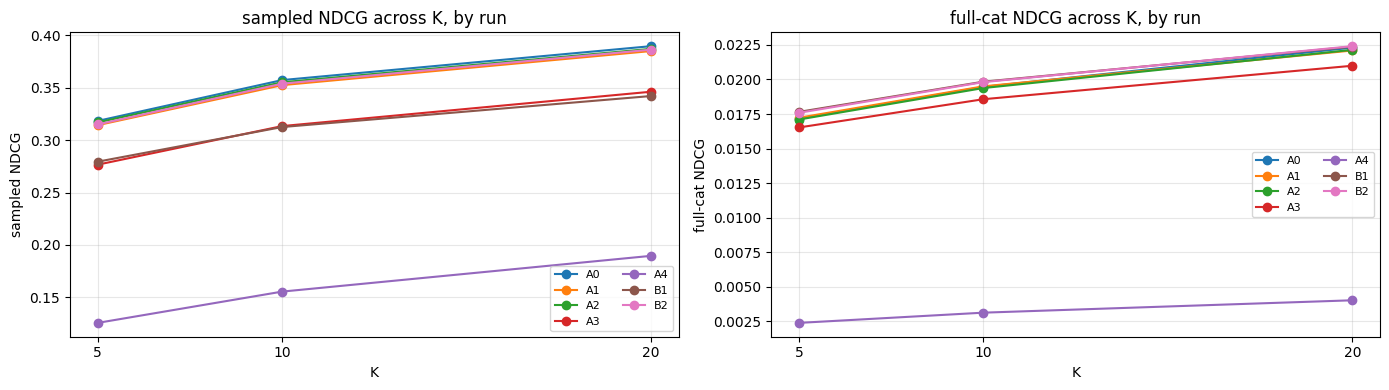

In [ ]:
# Multi-K view per metric type: how does each run rank across K in {5, 10, 20}?
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ks = [5, 10, 20]
for ax, prefix, title in [(axes[0], "sampled_ndcg_", "sampled NDCG"),
                           (axes[1], "full_ndcg_",    "full-cat NDCG")]:
    for _, row in res.iterrows():
        ax.plot(ks, [row[f"{prefix}{k}"] for k in ks], marker="o", label=row["run_id"])
    ax.set_xlabel("K"); ax.set_ylabel(title); ax.set_xticks(ks)
    ax.set_title(f"{title} across K, by run")
    ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/results_multi_k_lines.png", dpi=120, bbox_inches="tight")
plt.show()


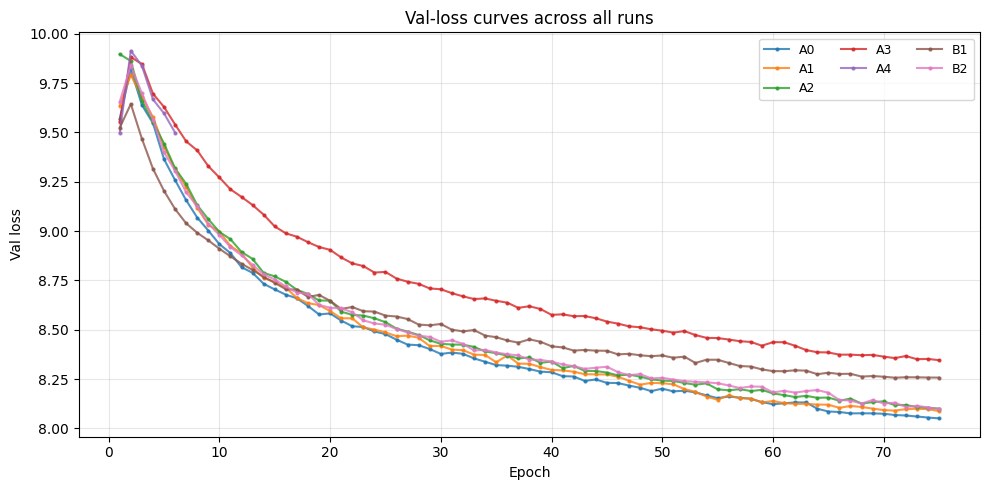

In [ ]:
# Overlay training curves across all runs (read from history CSVs)
fig, ax = plt.subplots(figsize=(10, 5))
for run_id in res["run_id"]:
    hist_path = f"{HISTORY_DIR}/{run_id}.csv"
    if not os.path.exists(hist_path):
        continue
    h = pd.read_csv(hist_path)
    ax.plot(h["epoch"], h["val_loss"], marker="o", markersize=2, label=run_id, alpha=0.8)
ax.set_xlabel("Epoch"); ax.set_ylabel("Val loss")
ax.set_title("Val-loss curves across all runs")
ax.grid(alpha=0.3); ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/results_val_loss_overlay.png", dpi=120, bbox_inches="tight")
plt.show()


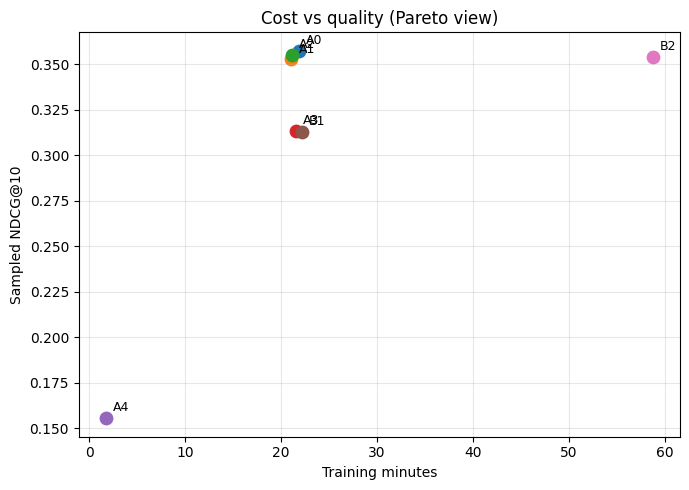

In [ ]:
# Pareto view: train wall-clock vs sampled NDCG@10
fig, ax = plt.subplots(figsize=(7, 5))
for _, row in res.iterrows():
    ax.scatter(row["train_minutes"], row["sampled_ndcg_10"], s=80)
    ax.annotate(row["run_id"], (row["train_minutes"], row["sampled_ndcg_10"]),
                textcoords="offset points", xytext=(5, 5), fontsize=9)
ax.set_xlabel("Training minutes")
ax.set_ylabel("Sampled NDCG@10")
ax.set_title("Cost vs quality (Pareto view)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/results_pareto.png", dpi=120, bbox_inches="tight")
plt.show()


## Final summary

Prints the best run per family and writes `final_summary.csv` + `experiments.csv` for easy viewing.

In [ ]:
# Final summary: best-per-family + overall wall-clock
res = pd.read_parquet(f"{RESULTS_DIR}/experiments.parquet")
best_per_family = res.sort_values("full_ndcg_10", ascending=False).groupby("family").head(1).sort_values("family")
summary_cols = ["run_id", "family", "full_ndcg_10", "full_recall_10", "full_precision_10",
                "full_mrr", "sampled_ndcg_10", "epochs_run", "train_minutes"]
print("Best run per family:")
print(best_per_family[summary_cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nTotal training wall-clock: {res['train_minutes'].sum():.1f} min across {len(res)} runs")
print(f"Peak GPU mem across runs:  {res['peak_gpu_mb'].max():.0f} MB")

best_per_family.to_csv(f"{RESULTS_DIR}/final_summary.csv", index=False)
res.to_csv(f"{RESULTS_DIR}/experiments.csv", index=False)  # also dump parquet as CSV for easy viewing
print(f"\nSaved: {RESULTS_DIR}/final_summary.csv and experiments.csv")


Best run per family:
run_id family  full_ndcg_10  full_recall_10  full_precision_10  full_mrr  sampled_ndcg_10  epochs_run  train_minutes
    A1      A        0.0195          0.0292             0.0029    0.0193           0.3525          75        21.0844
    B1      B        0.0198          0.0291             0.0029    0.0196           0.3125          75        22.1482

Total training wall-clock: 168.4 min across 7 runs
Peak GPU mem across runs:  2402 MB

Saved: /content/drive/My Drive/rec_system/newV2/results05_final/final_summary.csv and experiments.csv


In [ ]:
print("=" * 70)
print("  ALL DONE  —  Phase 4 experiments complete.")
print(f"  Results:     {RESULTS_DIR}/experiments.parquet ({len(res)} runs)")
print(f"  Best table:  {RESULTS_DIR}/final_summary.csv")
print(f"  Plots:       {PLOTS_DIR}/")
print(f"  Checkpoints: {CKPT_DIR}/")
print("=" * 70)


  ALL DONE  —  Phase 4 experiments complete.
  Results:     /content/drive/My Drive/rec_system/newV2/results05_final/experiments.parquet (7 runs)
  Best table:  /content/drive/My Drive/rec_system/newV2/results05_final/final_summary.csv
  Plots:       /content/drive/My Drive/rec_system/newV2/results05_final/plots05/
  Checkpoints: /content/drive/My Drive/rec_system/newV2/checkpoints05_final/
